# README
## Purpose
Perform exploratory data analysis on the Finnhub preprocessed model-input dataset.
## Inputs
- `Data/combined_timeline_data.csv`
## Outputs
- Schema checks, descriptive statistics, keyword frequency plots, and wordcloud visualizations.
## Notes
Use this notebook for dataset validation and exploratory profiling before modeling.

## Imports

In [1]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import plotly.express as px
import re

## Read Data

In [3]:
fraser_data = pd.read_csv('Data/combined_timeline_data.csv')
fraser_data['date'] = pd.to_datetime(fraser_data['Date'], errors='coerce')
if 'date_only' not in fraser_data.columns:
    fraser_data['date_only'] = fraser_data['date'].dt.date

print('Loaded new dataset: Data/combined_timeline_data.csv')

Loaded new dataset: Data/combined_timeline_data.csv


## Quick schema check

In [4]:
print('fraser shape:', fraser_data.shape)
print('\nfraser columns:', list(fraser_data.columns))
display(fraser_data[['Summary', 'date', 'date_only']].head(2))

fraser shape: (520, 8)

fraser columns: ['Date', 'Source', 'Summary', 'Associated Link Title', 'Associated Link URL', 'Theme', 'date', 'date_only']


,Summary,date,date_only
0,The World Health Organization (WHO) announces ...,2020-01-04,2020-01-04
1,The Centers for Disease Control and Prevention...,2020-01-08,2020-01-08


## Exploratory data analysis

,missing_count
Summary,0
date,64
date_only,64


Date range combined: 2007-02-27 -> 2022-05-25
Unique summaries: 512


,n_records
Summary,
"The S&P 500 Index declines by 7%, triggering a Level 1 market-wide circuit breaker trading halt. U.S. equity markets resume after 15 minutes.",4
The Office of the Special Inspector General for the Troubled Asset Relief Program issues its quarterly report to Congress on the operation of the Troubled Asset Relief Program.,4
The FOMC votes to maintain its target for the federal funds rate at 2.00 percent.,3
"The World Health Organization (WHO) announces that China has reported a cluster of pneumonia cases of unknown cause (with no deaths) in Wuhan, China.",1
"The Centers for Disease Control and Prevention (CDC) issues an official Health Advisory and a level 1 travel notice (""practice usual precautions"") in response to ""a reported cluster of pneumonia of unknown etiology"" in China.",1
"The CDC notes the appearance of a novel coronavirus outbreak in Wuhan City, Hubei Province, China. The CDC issues an interim travel health notice to people traveling to Wuhan City.",1
"The CDC and the Department of Homeland Security announce enhanced health screenings to detect ill travelers traveling to the United States on direct or connecting flights from Wuhan, China. Travelers from Wuhan to the United States will undergo entry screening for symptoms associated with 2019-nCoV at three U.S. airports that receive most of the travelers from Wuhan, China: San Francisco (SFO), New York (JFK), and Los Angeles (LAX) airports.",1
"The Washington State Department of Health announces the first confirmed case of COVID-19 in the United States in Snohomish County, Washington. The patient traveled from Wuhan City, China.",1
"The CDC confirms the first travel-related case of COVID-19 (patient from Washington) and announces the addition of two more airports—Chicago O'Hare (ORD) and Atlanta (ATL) to the coronavirus screening, funneling all passengers originating in Wuhan, China, through one of the five airports (SFO, JFK, LAX, ORD, and ATL).",1


,summary_len_stats
count,520.000000
mean,329.171154
std,232.308826
min,47.000000
25%,152.500000
50%,267.500000
75%,426.250000
max,2086.000000


,date_only,n_records
362,2022-01-03,1
363,2022-01-10,1
364,2022-01-31,1
365,2022-02-08,1
366,2022-02-28,1
367,2022-03-31,1
368,2022-04-18,1
369,2022-04-29,1
370,2022-05-03,1
371,2022-05-25,1


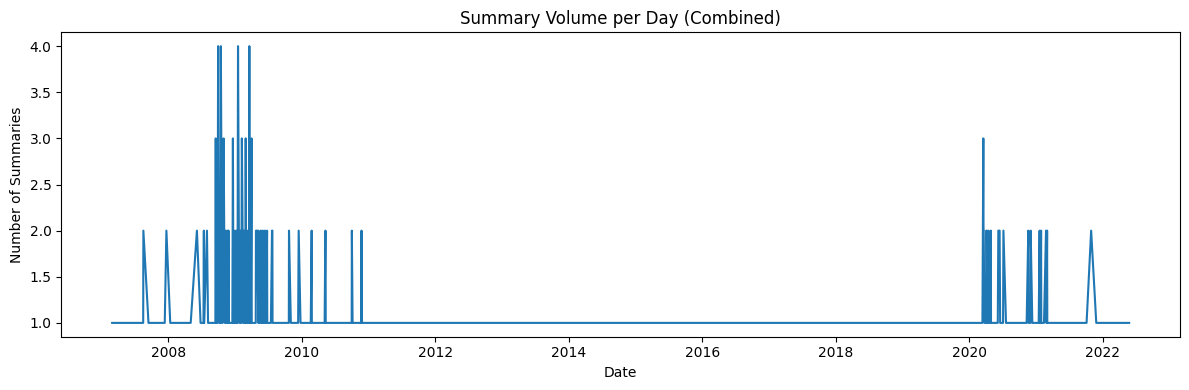

C:\Users\gianf\AppData\Local\Temp\ipykernel_24380\3248139203.py:36: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


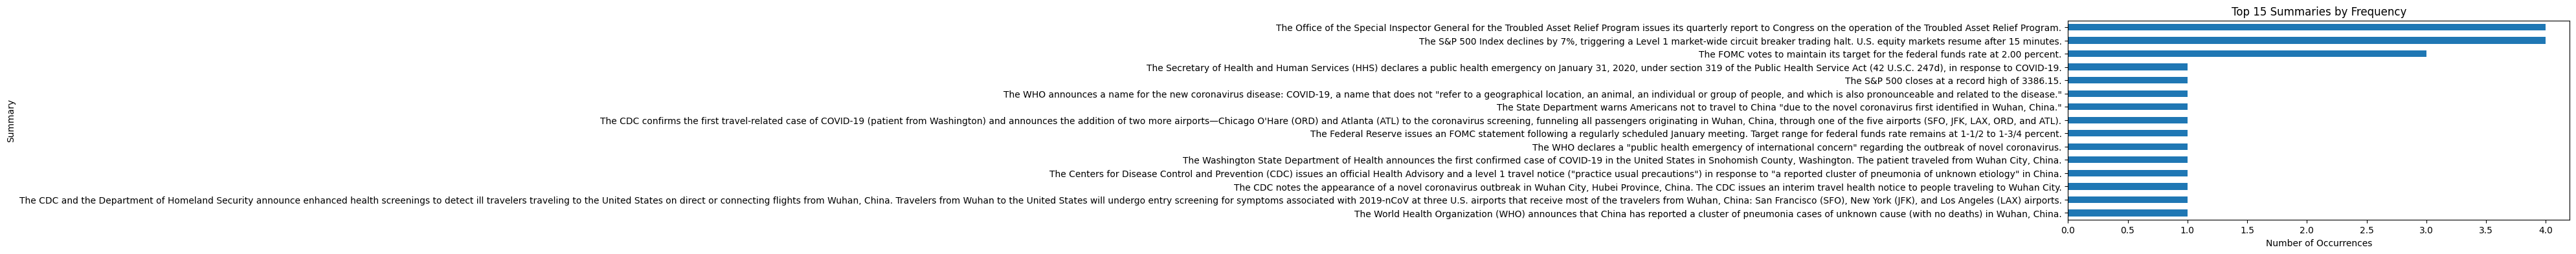

In [6]:
# quality checks
display(fraser_data[['Summary', 'date', 'date_only']].isna().sum().to_frame('missing_count'))
print('Date range combined:', fraser_data['date_only'].dropna().min(), '->', fraser_data['date_only'].dropna().max())
print('Unique summaries:', fraser_data['Summary'].nunique())

# top summaries (by frequency, if duplicates exist)
top_summaries = fraser_data['Summary'].value_counts().head(15)
display(top_summaries.rename_axis('Summary').to_frame('n_records'))

# summary length
fraser_data['summary_len'] = fraser_data['Summary'].str.len()
display(fraser_data['summary_len'].describe().to_frame('summary_len_stats'))

# daily volume
daily_counts = fraser_data.groupby('date_only').size().rename('n_records').reset_index()
display(daily_counts.tail(10))

try:
    import matplotlib.pyplot as plt
    # Remove rows with missing or invalid dates for plotting
    plot_counts = daily_counts[daily_counts['date_only'].apply(lambda x: pd.notnull(x))].copy()
    plot_counts['date_only'] = pd.to_datetime(plot_counts['date_only'])
    plt.figure(figsize=(12, 4))
    plt.plot(plot_counts['date_only'], plot_counts['n_records'])
    plt.title('Summary Volume per Day (Combined)')
    plt.xlabel('Date')
    plt.ylabel('Number of Summaries')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    top_summaries.sort_values().plot(kind='barh')
    plt.title('Top 15 Summaries by Frequency')
    plt.xlabel('Number of Occurrences')
    plt.ylabel('Summary')
    plt.tight_layout()
    plt.show()
except Exception as error:
    print('Plotting skipped:', error)

## Wordcloud

Using text column for EDA/wordcloud: Summary



Generating word cloud for summaries...


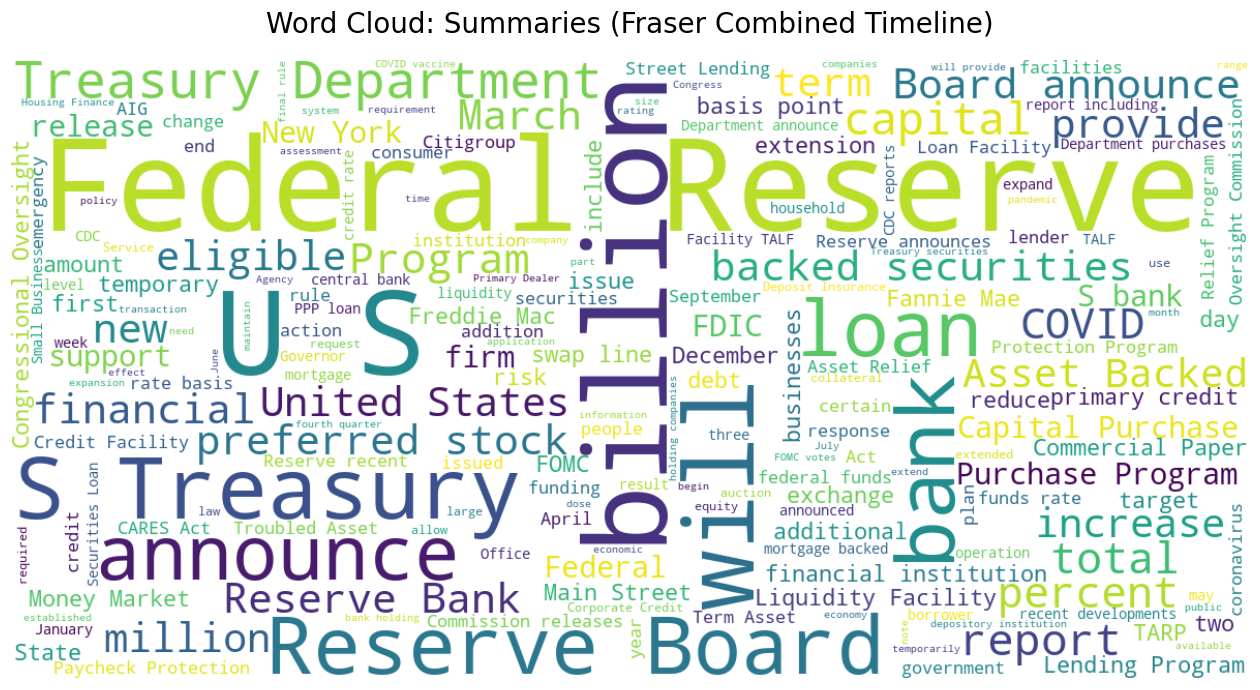

In [7]:
summary_col = 'Summary'
print(f'Using text column for EDA/wordcloud: {summary_col}')

# Clean and extract keywords from summaries
def extract_keywords(text):
    if pd.isna(text):
        return []
    words = re.findall(r'\b[a-z]{2,}\b', str(text).lower())
    stop_words = {'we', 'il', 'll', 'as', 'it', 'vs', 'at', 'be', 'our', 'use', 'or', 'let', 'but', 'us', 'by', 'more', 'come', 'have', 'the', 'and', 'for', 'with', 'how', 'your', 'using', 'from', 'into', 'this', 'that', 'are', 'was', 'you', 'what', 'can', 'in', 'to', 'of', 'is', 'an', 'do', 'de', 'on', 'not', 'why', 'will'}
    return [w for w in words if w not in stop_words]

all_summary_words = []
for summary in fraser_data[summary_col].dropna():
    all_summary_words.extend(extract_keywords(summary))

summary_word_freq = Counter(all_summary_words)
top_summary_words = pd.DataFrame(summary_word_freq.most_common(20), columns=['keyword', 'frequency'])

fig2 = px.bar(
    top_summary_words,
    x='keyword',
    y='frequency',
    title='Top 20 Keywords in Summaries (Fraser Combined Timeline)',
    labels={'keyword': 'Keyword', 'frequency': 'Frequency'},
    color='frequency',
    color_continuous_scale='Viridis'
 )
fig2.update_layout(showlegend=False, height=500)
fig2.show(renderer='iframe')

print("\nGenerating word cloud for summaries...")
summary_text = ' '.join(fraser_data[summary_col].dropna().astype(str))
wordcloud_summary = WordCloud(width=1200, height=600, background_color='white', colormap='viridis').generate(summary_text)
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud_summary, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud: Summaries (Fraser Combined Timeline)', fontsize=20, pad=20)
plt.tight_layout()
plt.show()

In [9]:
# Average summary length (characters + words) for Fraser dataset
summaries = fraser_data['Summary'].dropna().astype(str)

avg_chars = summaries.str.len().mean()
avg_words = summaries.str.split().str.len().mean()
min_words = summaries.str.split().str.len().min()
max_words = summaries.str.split().str.len().max()

print(f"Summaries analyzed: {len(summaries):,}")
print(f"Average summary length: {avg_chars:.2f} characters")
print(f"Average summary length: {avg_words:.2f} words")
print(f"Minimum summary length: {min_words} words")
print(f"Maximum summary length: {max_words} words")

Summaries analyzed: 520
Average summary length: 329.17 characters
Average summary length: 50.43 words
Minimum summary length: 7 words
Maximum summary length: 299 words
